# Creating GKP

In [10]:
import numpy as np
sqrt2 = np.sqrt(2)
π = np.pi
sqrt_π = np.sqrt(π)

from typing import Callable, Literal, TypeAlias, Final, ParamSpec, TypeVar, TypedDict, Optional, overload
from enum import Enum, auto

from qutip import (
	Qobj,
    basis, tensor, qeye, 
    displace, squeeze, destroy, create, position, momentum, squeezing,
    sigmax, sigmay, sigmaz, sigmap, sigmam,
)
from qutip.qip.operations import ry
from qutip.measurement import measurement_statistics_povm

# Fix path for Jupyter notebooks
import os
import sys
# Navigate to the project root (3 levels up from current notebook)
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
sys.path.append(project_root)

from src.quantum.qutip_support._common import fock_str
from src.quantum.states.density_matrices.translations import density_matrix_to_pure_state
from src.utils import tuples, numerics

## Visuals:
from src.utils.visuals import matplotlib_support
from src.quantum.visualizations.wigner_function import plot_plain_wigner


In [11]:

## For type hinting:
P = ParamSpec('P')
R = TypeVar('R')
CodeOptions : TypeAlias = Literal["squeezed", "displaced"] 
CreationMethod : TypeAlias = Literal["CNOD", "post-selection", "measurement-free"] 
C_kl_ij_Type : TypeAlias = dict[tuple[int, tuple[int, int]], complex]
_QuantumOpType = TypeVar("_QuantumOpType", Qobj, np.ndarray)


class ErrorFamily(Enum):
	PHOTON_LOSS = auto()
	PHOTON_GAIN = auto()
	DISPLACEMENT = auto()
	PHASE_ERROR = auto()


## look
def conditional_print(is_on:bool, *args, **kwargs) -> None:
	if not is_on:
		return
	for i, arg in enumerate(args):
		if isinstance(arg, Qobj):
			s = fock_str(arg)
			args = tuples.copy_with_replaced_val_at_index(args, i, s)

	print(*args, **kwargs)


def _op_str(op:str, l:int=20) -> str:
	# pad the string with spaces to get a string of `l` length:
	return f"{op:<{l}}"


class DeterministicParams(TypedDict):
    theta:     float  # in radians, 0 ≤ θ ≤ π
    phi:       float  # in radians, 0 ≤ φ < 2π
    beta_scale: float  # 0 < beta_scale ≤ 1  (default 1)


def _density_matrix_to_pure_state(rho:_QuantumOpType, check:bool=True) -> tuple[_QuantumOpType, float]:
	"""
	Convert a density matrix to its corresponding pure state vector.

	Parameters:
	rho (qutip.Qobj or numpy.ndarray): Density matrix representing a pure state

	Returns:
	numpy.ndarray: Pure state vector
	"""
	# If input is a QuTiP Qobj, convert to numpy array
	if isinstance(rho, Qobj):
		original_type = Qobj
		rho_matrix = rho.full()
	else:
		original_type = np.ndarray
		rho_matrix = np.array(rho)

	# Check if the matrix is Hermitian
	if not np.allclose(rho_matrix, rho_matrix.conj().T):
		raise ValueError("Input matrix is not Hermitian")

	# Compute eigenvalues and eigenvectors
	eigenvalues, eigenvectors = np.linalg.eigh(rho_matrix)

	# Find the eigenvalue close to 1 (for pure states)
	pure_state_index = np.argmin(np.abs(eigenvalues - 1))
	dominant_eigenvalue = eigenvalues[pure_state_index]
    
    # Extract the corresponding eigenvector (pure state)
	if check:
		assert np.isclose(dominant_eigenvalue, 1, rtol=1e-6), "Dominant eigenvalue is not close to 1"
	pure_state : np.ndarray = eigenvectors[:, pure_state_index]

	# Normalize the state vector
	pure_state /= np.linalg.norm(pure_state)

	## Return the pure state in the original type
	if original_type == Qobj:
		dims = (rho.dims[0][0], 1)  #type: ignore
		state_out = Qobj(pure_state, dims=dims)
	else:
		state_out = pure_state
	return state_out, dominant_eigenvalue  #type:ignore




def _v_k(k:int, N:int) -> float:
	if k == 1:
		return -sqrt_π * np.power(2, N-1)
	elif k > 1:
		return sqrt_π * np.power(2, N-k) 
	else:
		raise ValueError(f"Invalid k={k}, must be k >= 1")
	

def _w_k(k:int, N:int) -> float:
	if k == N:
		return sqrt_π/4
	elif k < N:
		return -sqrt_π/4 * np.power(2.0, -(N-k)) 
	else:
		raise ValueError(f"Invalid k={k}, must be k >= 1")


def print_(*args, **kwargs):
    return conditional_print(_print, *args, **kwargs)


def op_to_unitary(op: Qobj) -> Qobj:
    exponent = 1j*op
    unitary = exponent.expm()
    return unitary  


# Build Hilbert spaces & operators
I_light = qeye(num_moments)
qubit_0 = basis(2, 0)
qubit_1 = basis(2, 1)
qubit_plus = (qubit_0 + qubit_1)/sqrt2
qubit_minus = (qubit_0 - qubit_1)/sqrt2
light_0 = basis(num_moments, 0)


class MeasureStats(TypedDict):
    """
    Type for the light state, which is a tensor product of the light mode and a qubit state.
    """
    state: Qobj
    prob: float
    purity: float


@overload
def _measure_qubit_state(psi: Qobj, return_full_state:Literal[True]) -> list[MeasureStats]: ...
@overload
def _measure_qubit_state(psi: Qobj, return_full_state:Literal[False]) -> list[Qobj]: ...
def _measure_qubit_state(psi: Qobj, return_full_state:Literal[False, True]=False) -> list[MeasureStats]|list[Qobj]:
    # Measure qubit & post-select
    ops = [
		tensor(I_light, qubit_0.proj()), 
		tensor(I_light, qubit_1.proj())
	]
    collapsed_states, probabilities = measurement_statistics_povm(psi, ops)

    # Extract logical codewords
    light_states: list[Qobj] = []
    purity_values: list[float] = []
    for state in collapsed_states:
        light, purity = _density_matrix_to_pure_state(state.ptrace(0))
        light_states.append(light)
        purity_values.append(purity)
		
    if not return_full_state:
        return light_states
	
    res : list[MeasureStats] = [
		MeasureStats(
            state=light_states,
            prob=probabilities,
            purity=purity   
        ) for light_states, probabilities, purity in zip(light_states, probabilities, purity_values)
    ]
    return res
		

Initial              |ψ>= 0.60581|0, 0> - 0.39848|2, 0> + 0.32101|4, 0> - 0.27259|6, 0> + 0.23719|8, 0> - 0.20932|10, 0> + 0.18642|12, 0> - 0.16711|14, 0> + 0.15051|16, 0> - 0.13606|18, 0> + 0.12336|20, 0> - 0.11212|22, 0> + 0.10210|24, 0> - 0.09313|26, 0> + 0.08507|28, 0> - 0.07780|30, 0> + 0.07123|32, 0> - 0.06528|34, 0> + 0.05987|36, 0> - 0.05496|38, 0> + 0.05048|40, 0> - 0.04640|42, 0> + 0.04266|44, 0> - 1⁄√649|46, 0> + 0.03613|48, 0> - 0.03327|50, 0> + 0.03065|52, 0> - 0.02825|54, 0> + 0.02604|56, 0> - 0.02401|58, 0> + 1⁄√2038|60, 0> - 0.02044|62, 0> + 0.01886|64, 0> - 0.01741|66, 0> + 0.01608|68, 0> - 1⁄√4535|70, 0> + 0.01372|72, 0> - 0.01267|74, 0> + 0.01171|76, 0> - 0.01082|78, 0> + ...
displacement         |ψ>= 0|7, 1> + 0|8, 0> + 1⁄√4542712682|9, 1> + 1⁄√596041895|10, 0> + 1⁄√88416774|11, 1> + 1⁄√14725548|12, 0> + 1⁄√2737961|13, 1> + 1⁄√565865|14, 0> + 1⁄√129549|15, 1> + 0.00552|16, 0> + 0.01046|17, 1> + 0.01886|18, 0> + 0.03239|19, 1> + 0.05300|20, 0> + 0.08250|21, 1> + 0.12

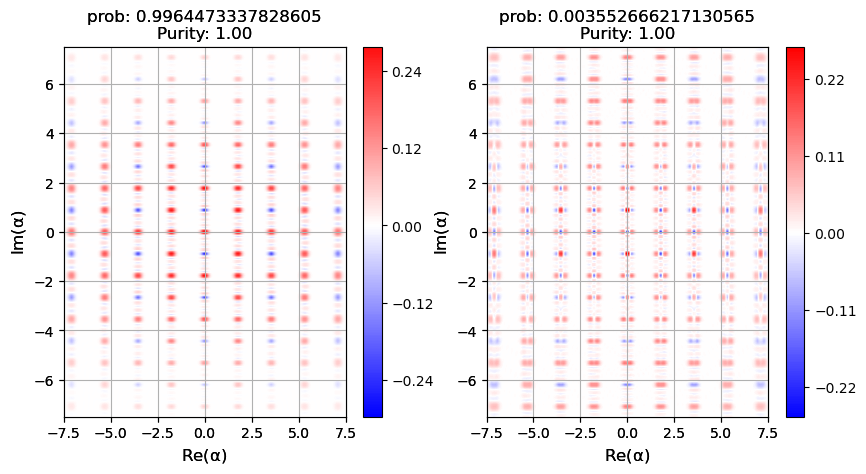

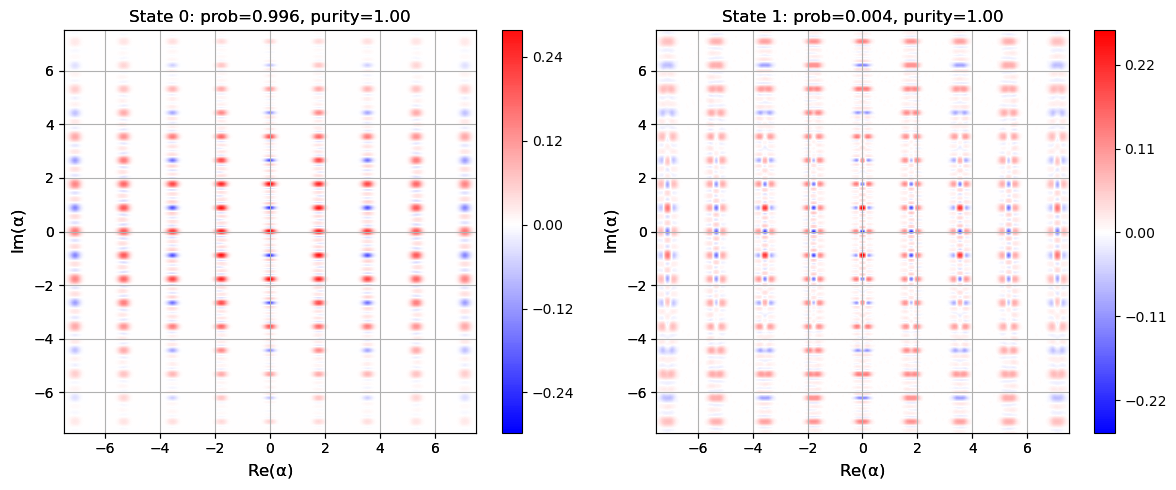

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

## Constants:
num_moments : Final[int] = 200


method: CreationMethod = "post-selection"
_print = True
	
X = position(num_moments)
P = momentum(num_moments)
σ_x = sigmax()
σ_y = sigmay()

N = 3

squeeze_db = 16.6  # dB
squeezed_light = squeeze(num_moments, squeeze_db/10) @ light_0

psi = tensor(squeezed_light, qubit_0)
print_(_op_str("Initial"),      "|ψ>=", psi)

for k in range(1, N+1):
    ## Displacement 
    v_k = _v_k(k, N) 
    Vk = op_to_unitary( v_k * tensor(P, σ_x) )
    psi = Vk @ psi
    print_(_op_str("displacement"),     "|ψ>=", psi)

    ## Disentanglement
    w_k = _w_k(k, N)
    Wk = op_to_unitary( w_k * tensor(X, σ_y) )
    psi = Wk @ psi
    print_(_op_str("disentanglement"),   "|ψ>=", psi)
            

light_states_with_stats = _measure_qubit_state(psi, return_full_state=True)
# Get state with highest probability:
probable_state_with_stats = max(light_states_with_stats, key=lambda x: x['prob'])
prob = probable_state_with_stats['prob']
purity = probable_state_with_stats['purity']
state = [probable_state_with_stats['state']]



## Plot:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, st in enumerate(light_states_with_stats):
    prob = st['prob']
    purity = st['purity']
    state = st['state']
    title = f"State {i}: prob={prob:.3f}, purity={purity:.2f}"
    plot_plain_wigner(state, ax=axes[i], title=title)

plt.tight_layout()
# plt.show()
